# He II 1640Å 재결합 방출선 Emissivity 계산

---

## 개요

이 노트북은 QSO 주변 CGM에서 **He II 1640Å 재결합 방출선**의 emissivity를 세 가지 방법으로 계산하고 비교한다.

### 물리적 배경

He II 1640Å는 수소유사(H-like) 이온인 He²⁺의 **n=3→2 전이**에 해당한다 (Z=2).
재결합 반응은 다음과 같다:

$$\mathrm{He}^{3+} + e^- \;\longrightarrow\; \mathrm{He}^{2+*} \;\longrightarrow\; \mathrm{He}^{2+} + h\nu_{1640}$$

따라서 emissivity의 rate는 **n(He³⁺) × n_e** 에 비례한다 (재결합하는 쪽이 He³⁺).

**Case B 조건**: He II Lyα (303.78Å, n=2→1) 광자는 nebula에서 광학적으로 두꺼워 즉시 재흡수됨 → n=2로 직접 재결합하는 경우 1640Å 기여 없음.

$$\varepsilon_{1640}(r) = j_{1640}(T_e(r),\,n_e(r)) \times n_e(r) \times n(\mathrm{He}^{3+})(r)$$
$$j_{1640} = h\nu_{1640} \times \alpha_{\rm eff}^B(T_e,\,n_e) \quad [\mathrm{erg\cdot s^{-1}\cdot cm^3}]$$

---

### 계산 방법 3가지

| 방법 | 설명 | 데이터 출처 |
|---|---|---|
| **Cloudy** | 완전한 photoionization 모델, 탈출확률·충돌 포함 | `HE_2_164043A` 라인 직접 읽기 |
| **PyNeb Case B** | Storey & Hummer (1995) 테이블 interpolation | T 유효범위: 500–30,000 K |
| **Seaton (1959) Kramers** | 해석적 근사 (Gaunt factor = 1) | $\alpha_n = \frac{5.197\times10^{-14}Z}{n}x_n^3 e^{x_n}E_1(x_n)$ |

---

### 주요 수정 사항 (v1)

1. **n(He²⁺) → n(He³⁺) 수정**  
   기존 코드에서 `nden_HeII`를 사용했으나, 재결합 rate는 재결합하는 이온인 **He³⁺**의 수밀도를 써야 한다.  
   `nden_HeII`(He²⁺)는 이미 재결합이 완료된 이온으로, 틀린 density였다.

2. **Seaton 공식의 `* n` 오류 제거**  
   `alpha_n_seaton(n, Te)`는 레벨 n의 모든 l(= 0, 1, …, n−1)을 이미 합산한 값이다.  
   기존 `alpha_B_total`에서 `* n`을 추가로 곱하면 이중 합산이 되어 틀리다.

3. **저온 overflow 방지**  
   모델 외곽의 차가운 CGM zone (T ~ 100 K)에서 $x_n = E_n/kT \gg 1$ → `exp(x_n)` 발산.  
   $x_n \geq 500$ 구간은 점근식 $x^3 e^x E_1(x) \approx x^2$ 으로 대체.

---

### 결과 요약 (Lum=44.0, Z=1.0, log N_H=22.0)

| 방법 | ∫ ε dr [erg/s/cm²] | Cloudy 대비 비율 |
|---|---|---|
| Cloudy | 7.27e-05 | 1.00 |
| PyNeb Case B | 9.41e-05 | 1.29 |
| Seaton Kramers (n≥3) | 1.17e-04 | 1.61 |

Cloudy 대비 PyNeb이 ~30% 높은 이유: Cloudy는 line escape probability와 photoionization에 의한 보정을 포함하기 때문.  
Seaton이 PyNeb보다 높은 이유: Kramers 근사가 Gaunt factor를 1로 고정해 실제보다 단면적을 과대평가함.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy import constants as const
from scipy.special import exp1
import warnings
warnings.filterwarnings('ignore')

kpc   = const.kpc.cgs.value
h_cgs = 6.626e-27
k_B   = 1.381e-16
c_cgs = 3e10

HE2 = pn.RecAtom('He', 2)
print(f'PyNeb version: {pn.__version__}')

warng pyCloudy config: pyCloudy works better with matplotlib Triangulation
PyNeb version: 1.1.30


## 1. 파라미터 설정

In [2]:
Lumin                = 41.0   # log L [erg/s]
metals               = 1.0    # metallicity (solar)
Column_density_order = 20.5   # log N_H [cm⁻²]

frac_He = 0.10
WAVE    = 1640              # Å
H_NU    = h_cgs * c_cgs / (WAVE * 1e-8)   # hν [erg]

## 2. Cloudy 모델 불러오기

In [3]:
import sys, os
sys.path.insert(0, os.path.expanduser('~/RT_JIN'))
from RT_v1 import resolve_column_density_path

path = resolve_column_density_path(Lumin, metals, Column_density_order, 'CIV/CLOUDY_QSO')
print('Cloudy 경로:', path)
Mod = pc.CloudyModel(path)

Cloudy 경로: /home/jinlim/CIV_RT_scat_data/CLOUDY_setup/Lum_41.0_2/metal_1.0/N_H_3.2_20.0/CIV/CLOUDY_QSO


In [4]:
def read_ele(path, element, ion_stage):
    """Cloudy .ele 파일에서 이온 분율 읽기"""
    data = np.genfromtxt(f'{path}.ele_{element}')
    return data[:, ion_stage]

nH         = Mod.nH
n_He       = nH * frac_He
Te         = Mod.te          # 전자온도 [K], 반경별 profile
ne         = Mod.ne          # 전자밀도 [cm⁻³]
dr         = Mod.dr          # zone 두께 [cm]
radius_kpc = Mod.radius / kpc
radius_cm  = Mod.radius

HeI_frac   = read_ele(path, 'He', 1)
HeII_frac  = read_ele(path, 'He', 2)
HeIII_frac = read_ele(path, 'He', 3)
nden_HeII  = HeII_frac  * n_He
nden_HeIII = HeIII_frac * n_He   # He³⁺: 재결합 반응의 주체

# Cloudy 직접 계산 emissivity [erg/s/cm³]
emis_cloudy = Mod.get_emis('HE_2_164043A')

print(f'Zones: {len(Te)}')
print(f'T_e  : {Te.min():.0f} – {Te.max():.0f} K')
print(f'n_e  : {ne.min():.2e} – {ne.max():.2e} cm⁻³')
print(f'n(He³⁺): {nden_HeIII.min():.2e} – {nden_HeIII.max():.2e} cm⁻³')

Zones: 372
T_e  : 174 – 26604 K
n_e  : 3.95e-06 – 2.90e-03 cm⁻³
n(He³⁺): 1.96e-09 – 2.40e-04 cm⁻³


## 3. Case B emissivity — PyNeb (Storey & Hummer 1995)

$$j_{1640}(T_e, n_e) = h\nu_{1640} \times \alpha_{\rm eff}^B(T_e, n_e) \quad [\rm erg\cdot s^{-1}\cdot cm^3]$$

- `product=False`: 각 zone을 pairwise 계산 (default `True`는 T × n_e 2D grid)
- T > 30,000 K: Storey & Hummer (1995) 테이블 상한 초과 → NaN

In [5]:
T_MAX_PYNEB = 30000.0   # K

j_pyneb    = HE2.getEmissivity(Te, ne, wave=WAVE, product=False)
alpha_eff  = j_pyneb / H_NU            # α_eff^B [cm³/s]
emis_caseB = j_pyneb * ne * nden_HeIII # ε [erg/s/cm³]


# mask_outT = Te > T_MAX_PYNEB

# print(Te[mask_outT])
# print(f'T > {T_MAX_PYNEB:.0f} K : {mask_outT.sum()} zones → NaN  (T_max = {Te[mask_outT].max():.0f} K)')

ratio_pyneb = np.where(emis_cloudy > 0, emis_caseB / emis_cloudy, np.nan)

## 4. Seaton (1959) Kramers 근사

$$\alpha_n(T_e) = \frac{5.197\times10^{-14}\,Z}{n}\,x_n^3\,e^{x_n}\,E_1(x_n), \quad x_n = \frac{Z^2 \times 13.6\,\text{eV}}{n^2\, k_B T_e}$$

- n의 **모든 l 합산값** → `* n` 추가 금지
- $x_n \gg 1$ (저온) overflow 방지: $x_n \geq 500$ 구간은 $x^3 e^x E_1(x) \approx x^2$ 점근식 사용
- Case B 총계: $\alpha^B = \sum_{n=2}^{\infty}\alpha_n$
- 1640Å 근사: $\alpha_{\rm eff}^{\rm Stn}(1640) \approx \sum_{n=3}^{\infty}\alpha_n$ (n=2 재결합 → 303Å OTS 재흡수)

In [6]:
def alpha_n_seaton(n, Te, Z=2, x_thresh=500.0):
    """
    Seaton (1959) Kramers: 레벨 n 재결합 계수 (모든 l 합산) [cm³/s]
    x_n >= x_thresh 구간은 점근식으로 overflow 방지.
    """
    Te     = np.asarray(Te, dtype=float)
    E_n    = Z**2 * 13.6 * 1.602e-12 / n**2
    x_n    = E_n / (k_B * Te)
    safe_x = np.clip(x_n, 1e-300, x_thresh)
    body   = np.where(x_n < x_thresh,
                      safe_x**3 * np.exp(safe_x) * exp1(safe_x),
                      x_n**2)
    return 5.197e-14 * Z / n * body


def alpha_B_seaton(Te, Z=2, n_max=100):
    """Case B 총 재결합 계수: n=2부터 합산 [cm³/s]"""
    return sum(alpha_n_seaton(n, Te, Z) for n in range(2, n_max + 1))


def alpha_eff_seaton_1640(Te, Z=2, n_max=100):
    """
    1640Å α_eff 근사: n≥3 합산 [cm³/s]
    n=2 직접 재결합 → 303Å OTS 재흡수 → 1640Å 기여 없음
    """
    return sum(alpha_n_seaton(n, Te, Z) for n in range(3, n_max + 1))

In [7]:
aB_seaton    = alpha_B_seaton(Te)
aeff_seaton  = alpha_eff_seaton_1640(Te)


emis_seaton_B  = aB_seaton * H_NU * ne * nden_HeIII
emis_seaton  = aeff_seaton * H_NU * ne * nden_HeIII
ratio_seaton = np.where(emis_cloudy > 0, emis_seaton / emis_cloudy, np.nan)

## 5. 결과 요약

In [8]:
int_cloudy = np.trapz(emis_cloudy,                   radius_cm)
int_pyneb  = np.trapz(np.nan_to_num(emis_caseB),     radius_cm)
int_seaton = np.trapz(np.nan_to_num(emis_seaton),    radius_cm)

j_ref  = HE2.getEmissivity(1e4, 100., wave=WAVE)
a_ref  = j_ref / H_NU

print(f'He II {WAVE}Å  |  Lum={Lumin}, Z={metals}, logNH={Column_density_order}')
print(f'  ∫ emis dr  Cloudy       : {int_cloudy:.3e} erg/s/cm²  (ratio 1.00)')
print(f'  ∫ emis dr  PyNeb Case B : {int_pyneb:.3e} erg/s/cm²  (ratio {int_pyneb/int_cloudy:.2f})')
print(f'  ∫ emis dr  Seaton n≥3   : {int_seaton:.3e} erg/s/cm²  (ratio {int_seaton/int_cloudy:.2f})')
print()
print(f'  j_1640  @ T=10⁴K, ne=100 : {j_ref:.3e} erg·s⁻¹·cm³')
print(f'  α_eff^B @ T=10⁴K, ne=100 : {a_ref:.3e} cm³/s')

He II 1640Å  |  Lum=41.0, Z=1.0, logNH=20.5
  ∫ emis dr  Cloudy       : 9.426e-08 erg/s/cm²  (ratio 1.00)
  ∫ emis dr  PyNeb Case B : 1.451e-07 erg/s/cm²  (ratio 1.54)
  ∫ emis dr  Seaton n≥3   : 3.041e-07 erg/s/cm²  (ratio 3.23)

  j_1640  @ T=10⁴K, ne=100 : 9.815e-24 erg·s⁻¹·cm³
  α_eff^B @ T=10⁴K, ne=100 : 8.098e-13 cm³/s


## 6. α_eff 반경 프로파일 비교

Font 'default' does not have a glyph for '\ucd1d' [U+cd1d], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uacc4' [U+acc4], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubc18' [U+bc18], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uacbd' [U+acbd], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ud504' [U+d504], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub85c' [U+b85c], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ud30c' [U+d30c], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc77c' [U+c77c], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ucd1d' [U+cd1d], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uacc4' [U+acc4], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubc18' [U+bc18], 

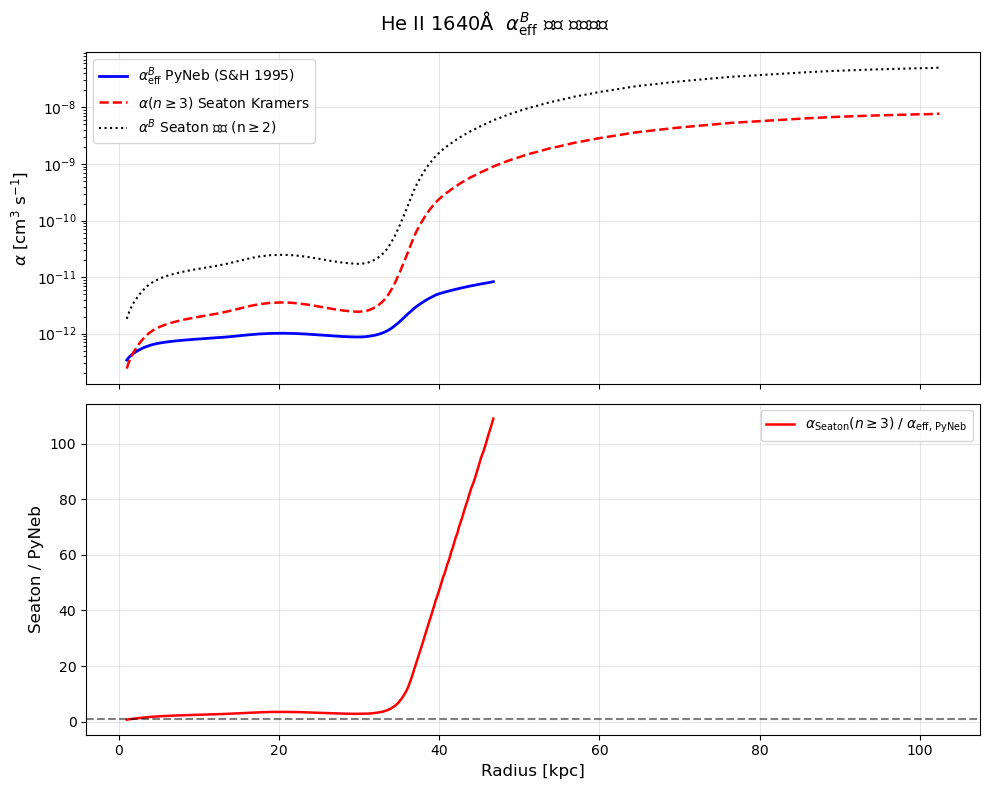

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle(r'He II 1640Å  $\alpha_{\rm eff}^B$ 반경 프로파일', fontsize=14)

ax = axes[0]
ax.plot(radius_kpc, alpha_eff,   'b-',  lw=2,   label=r'$\alpha_{\rm eff}^B$ PyNeb (S&H 1995)')
ax.plot(radius_kpc, aeff_seaton, 'r--', lw=1.8, label=r'$\alpha(n\geq3)$ Seaton Kramers')
ax.plot(radius_kpc, aB_seaton,   'k:',  lw=1.5, label=r'$\alpha^B$ Seaton 총계 (n$\geq$2)')
ax.set_yscale('log')
ax.set_ylabel(r'$\alpha$ [cm$^3$ s$^{-1}$]', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(radius_kpc, aeff_seaton / alpha_eff, 'r-', lw=1.8,
        label=r'$\alpha_{\rm Seaton}(n\geq3)\;/\;\alpha_{\rm eff,\,PyNeb}$')
ax.axhline(1.0, color='k', ls='--', alpha=0.5)
ax.set_ylabel('Seaton / PyNeb', fontsize=12)
ax.set_xlabel('Radius [kpc]', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 3-way Emissivity 비교 (Cloudy / PyNeb / Seaton)

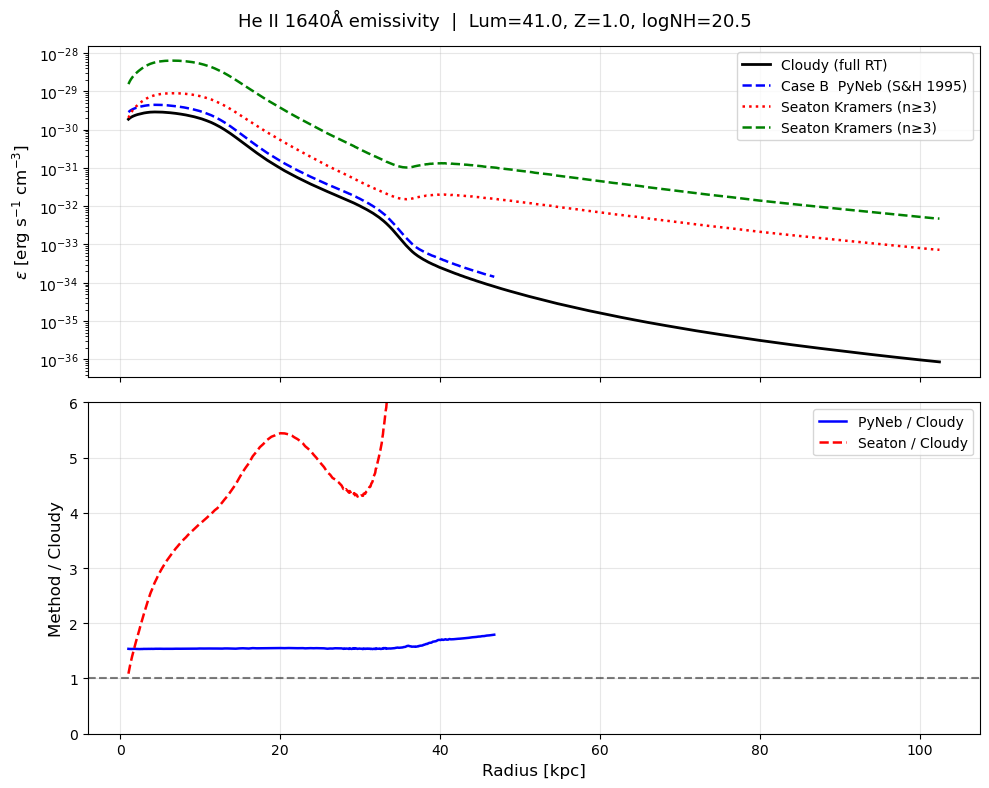

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle(f'He II {WAVE}Å emissivity  |  Lum={Lumin}, Z={metals}, logNH={Column_density_order}',
             fontsize=13)

ax = axes[0]
ax.plot(radius_kpc, emis_cloudy, 'k-',  lw=2,   label='Cloudy (full RT)')
ax.plot(radius_kpc, emis_caseB,  'b--', lw=1.8, label='Case B  PyNeb (S&H 1995)')
ax.plot(radius_kpc, emis_seaton, 'r:',  lw=1.8, label='Seaton Kramers (n≥3)')
ax.plot(radius_kpc, emis_seaton_B, 'g--',  lw=1.8, label='Seaton Kramers (n≥3)')

# emis_seaton_B
ax.set_yscale('log')
ax.set_ylabel(r'$\varepsilon$ [erg s$^{-1}$ cm$^{-3}$]', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(radius_kpc, ratio_pyneb,  'b-',  lw=1.8, label='PyNeb / Cloudy')
ax.plot(radius_kpc, ratio_seaton, 'r--', lw=1.8, label='Seaton / Cloudy')
ax.axhline(1.0, color='k', ls='--', alpha=0.5)
ax.set_ylabel('Method / Cloudy', fontsize=12)
ax.set_xlabel('Radius [kpc]', fontsize=12)
ax.set_ylim(0, 6)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'HeII_3way_L{Lumin}_Z{metals}_N{Column_density_order}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. He 이온화 분율 프로파일

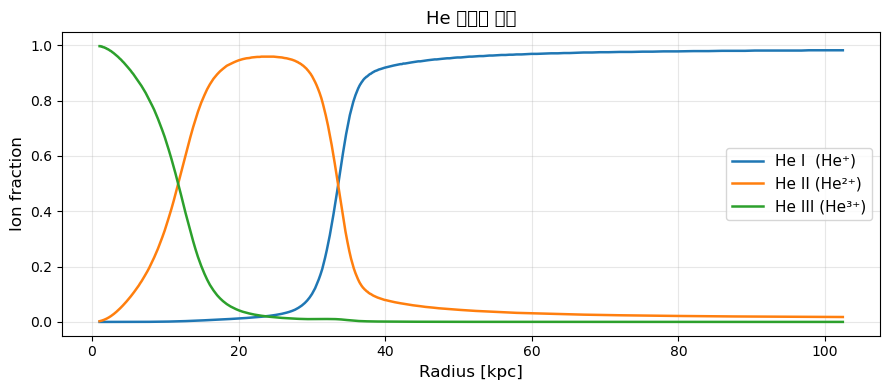

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(radius_kpc, HeI_frac,   label='He I  (He⁺)',   lw=1.8)
ax.plot(radius_kpc, HeII_frac,  label='He II (He²⁺)',  lw=1.8)
ax.plot(radius_kpc, HeIII_frac, label='He III (He³⁺)', lw=1.8)
ax.set_xlabel('Radius [kpc]', fontsize=12)
ax.set_ylabel('Ion fraction', fontsize=12)
ax.legend(fontsize=11)
ax.set_title('He 이온화 구조', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. α_eff^B vs T 테이블 (PyNeb & Seaton)

In [12]:
T_grid = np.array([5000., 8000., 10000., 15000., 20000., 30000.])
ne_ref = 100.0

print('T [K]    α_eff PyNeb   α(n≥3)Seaton  Seaton/PyNeb')
print('-' * 55)
for T in T_grid:
    j_p  = HE2.getEmissivity(T, ne_ref, wave=1640)
    a_p  = j_p / H_NU
    a_s  = alpha_eff_seaton_1640(T)
    print(f'{T:8.0f}  {a_p:12.3e}  {a_s:13.3e}  {a_s/a_p:11.3f}')

print()
print('→ Seaton은 Gaunt factor=1 근사 → 저T(~5000K)에서 ~6배 과대평가')
print('→ T~20000K 근방에서 PyNeb과 근접')

T [K]    α_eff PyNeb   α(n≥3)Seaton  Seaton/PyNeb
-------------------------------------------------------
    5000     1.440e-12      8.619e-12        5.987
    8000     9.765e-13      3.228e-12        3.306
   10000     8.098e-13      2.014e-12        2.487
   15000     5.705e-13      8.451e-13        1.481
   20000     4.422e-13      4.520e-13        1.022
   30000     3.058e-13      1.843e-13        0.602

→ Seaton은 Gaunt factor=1 근사 → 저T(~5000K)에서 ~6배 과대평가
→ T~20000K 근방에서 PyNeb과 근접


## 10. 여러 모델 파라미터 비교

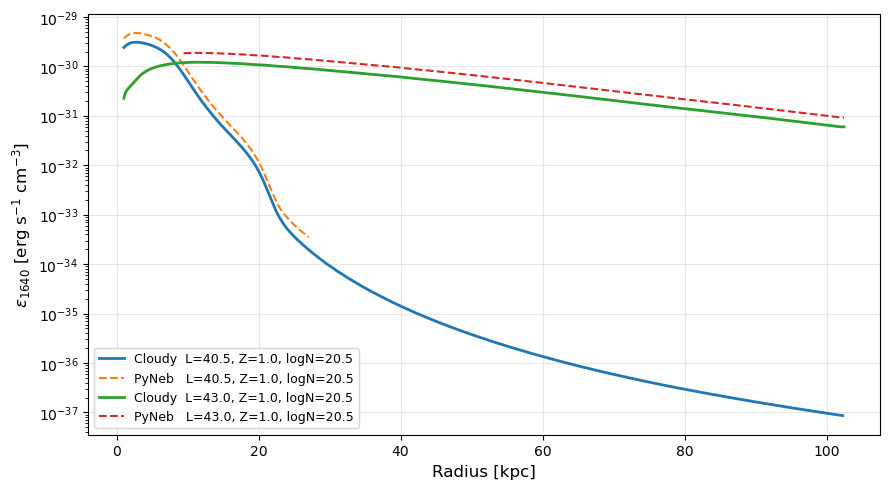

In [21]:
# 비교할 모델 목록에 추가
models = [
    (40.5, 1.0, 20.5),
    (43.0, 1.0, 20.5),
    # (44.0, 0.1, 22.0),
]

fig, ax = plt.subplots(figsize=(9, 5))

for Lum_i, Z_i, N_i in models:
    path_i   = resolve_column_density_path(Lum_i, Z_i, N_i, 'CIV/CLOUDY_QSO')
    Mod_i    = pc.CloudyModel(path_i)
    nH_i     = Mod_i.nH
    Te_i     = Mod_i.te
    ne_i     = Mod_i.ne
    nHeIII_i = read_ele(path_i, 'He', 3) * nH_i * frac_He
    r_kpc_i  = Mod_i.radius / kpc

    emis_c_i = Mod_i.get_emis('HE_2_164043A')
    j_i      = HE2.getEmissivity(Te_i, ne_i, wave=WAVE, product=False)
    emis_b_i = j_i * ne_i * nHeIII_i
    emis_s_i = alpha_eff_seaton_1640(Te_i) * H_NU * ne_i * nHeIII_i

    lbl = f'L={Lum_i}, Z={Z_i}, logN={N_i}'
    ax.plot(r_kpc_i, emis_c_i, lw=2,   label=f'Cloudy  {lbl}')
    ax.plot(r_kpc_i, emis_b_i, lw=1.5, ls='--', label=f'PyNeb   {lbl}')
    # ax.plot(r_kpc_i, emis_s_i, lw=1.2, ls=':',  label=f'Seaton  {lbl}')

ax.set_yscale('log')
ax.set_xlabel('Radius [kpc]', fontsize=12)
ax.set_ylabel(r'$\varepsilon_{1640}$ [erg s$^{-1}$ cm$^{-3}$]', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
# ax.set_title('He II 1640Å — Cloudy / PyNeb / Seaton 비교')
plt.tight_layout()
plt.show()

## 11. He II Level Populations — Cloudy zone-by-zone

Cloudy는 각 zone에서 He II (H-like He²⁺)의 모든 레벨 수밀도를 **통계적 평형 방정식**으로 풀어낸다.

**레벨 번호 규칙 (H-like, nl resolved)**:

| n | l = 0..n-1 | Cloudy index (0-based) |
|---|---|---|
| 1 | 1s | He+[1] |
| 2 | 2s, 2p | He+[2], He+[3] |
| 3 | 3s, 3p, 3d | He+[4], He+[5], He+[6] |
| n | n개 | start = n(n-1)/2 |

He II 1640Å (n=3→2) 의 emissivity는 다음으로 검증 가능:
$$\varepsilon_{1640} = \bigl[n_{3s}\,A_{3s\to2p} + n_{3p}\,A_{3p\to2s} + n_{3d}\,A_{3d\to2p}\bigr]\,h\nu_{1640}$$

**사용 모델**: Lum=44.0, Z=1.0, logN_H=22.0  (`~/RT_JIN/level_pop_test/`)

In [14]:
import os

lev_dir  = os.path.expanduser('~/RT_JIN/level_pop_test')

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
dat_lp   = np.genfromtxt(f'{lev_dir}/CLOUDY_QSO_popHe+_pops.dat', skip_header=1)
phy_lp   = np.genfromtxt(f'{lev_dir}/CLOUDY_QSO_pop.phy',         skip_header=1)
rad_lp   = np.genfromtxt(f'{lev_dir}/CLOUDY_QSO_pop.rad',         skip_header=1)

nz_lp    = min(len(dat_lp), len(rad_lp), len(phy_lp))
lev      = dat_lp[:nz_lp, 1:]      # (nz, 168)  He+[1]..He+[168]
r_lp_kpc = rad_lp[:nz_lp, 1] / kpc
Te_lp    = phy_lp[:nz_lp, 1]
ne_lp    = phy_lp[:nz_lp, 3]

# ── H-like 레벨 인덱스 ────────────────────────────────────────────────────────
def sidx(n):
    return n * (n - 1) // 2          # n번 주양자수의 시작 0-index

def n_sum(n):                        # n 레벨 전체 수밀도 (모든 l 합산)
    return lev[:, sidx(n):sidx(n)+n].sum(axis=1)

n_pops   = {n: n_sum(n) for n in range(1, 11)}
s2, s3   = sidx(2), sidx(3)
n2s, n2p = lev[:, s2],   lev[:, s2+1]
n3s, n3p, n3d = lev[:, s3], lev[:, s3+1], lev[:, s3+2]

# ── A-values He II (Z=2 H-like, NIST 기준) ───────────────────────────────────
hnu_1640 = h_cgs * c_cgs / (1640.4e-8)   # erg
A_3d_2p  = 1.033e9    # s⁻¹  (dominant, E1)
A_3p_2s  = 3.600e8    # s⁻¹
A_3s_2p  = 2.670e8    # s⁻¹
emis_levpop = (n3d*A_3d_2p + n3p*A_3p_2s + n3s*A_3s_2p) * hnu_1640

# Cloudy 직접 emissivity (검증용)
emis_raw_lp   = np.genfromtxt(f'{lev_dir}/CLOUDY_QSO_pop.emis', skip_header=1)[:nz_lp]
emis_c_lp     = emis_raw_lp[:, 10]     # He II 1640.43Å

print(f'Level-pop 모델: Lum=44.0, Z=1.0, logN_H=22.0  ({nz_lp} zones)')
print(f'n(He+, n=1) peak = {n_pops[1].max():.3e} cm⁻³  (ground state)')
print(f'n(He+, n=2) peak = {n_pops[2].max():.3e} cm⁻³')
print(f'n(He+, n=3) peak = {n_pops[3].max():.3e} cm⁻³  (1640Å upper state)')
print(f'  → 3s {n3s.max():.2e}, 3p {n3p.max():.2e}, 3d {n3d.max():.2e}')
print(f'Cloudy  emis(1640) peak = {emis_c_lp.max():.3e} erg/s/cm³')
print(f'LevPop  emis(1640) peak = {emis_levpop.max():.3e} erg/s/cm³')
print(f'비율 (LevPop/Cloudy)     = {emis_levpop.max()/emis_c_lp.max():.3f}  (A-value 근사 오차)')

Level-pop 모델: Lum=44.0, Z=1.0, logN_H=22.0  (479 zones)
n(He+, n=1) peak = 5.047e-03 cm⁻³  (ground state)
n(He+, n=2) peak = 1.125e-19 cm⁻³
n(He+, n=3) peak = 2.993e-25 cm⁻³  (1640Å upper state)
  → 3s 1.54e-25, 3p 3.54e-26, 3d 1.12e-25
Cloudy  emis(1640) peak = 1.746e-27 erg/s/cm³
LevPop  emis(1640) peak = 2.050e-27 erg/s/cm³
비율 (LevPop/Cloudy)     = 1.174  (A-value 근사 오차)


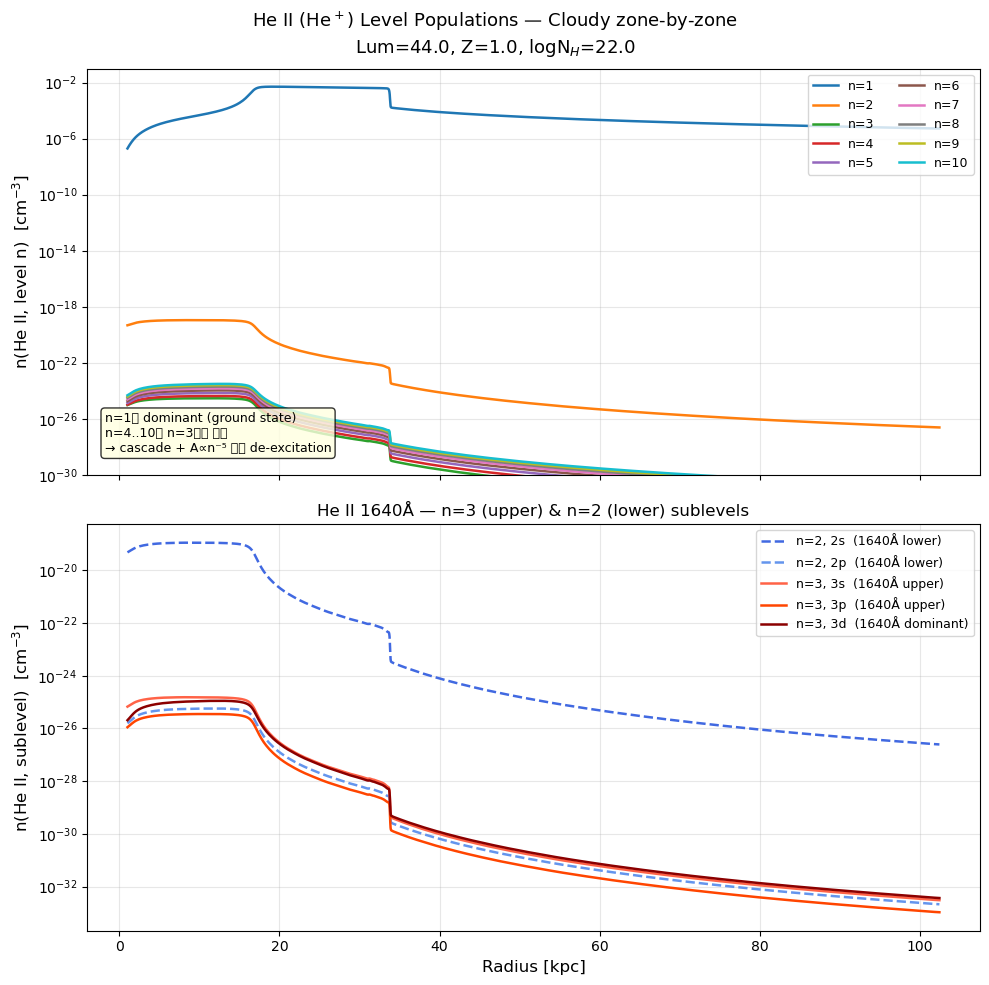

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig.suptitle('He II (He$^+$) Level Populations — Cloudy zone-by-zone\n'
             'Lum=44.0, Z=1.0, logN$_H$=22.0', fontsize=13)

# ── (상) n=1..10 수밀도 프로파일 ─────────────────────────────────────────────
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for n in range(1, 11):
    valid = n_pops[n] > 1e-40
    if valid.sum() > 2:
        ax.semilogy(r_lp_kpc[valid], n_pops[n][valid],
                    color=colors[n-1], lw=1.8, label=f'n={n}')
ax.set_ylabel('n(He II, level n)  [cm$^{-3}$]', fontsize=12)
ax.legend(fontsize=9, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(1e-30, 1e-1)
ax.text(0.02, 0.05, 'n=1이 dominant (ground state)\nn=4..10이 n=3보다 높음\n→ cascade + A∝n⁻⁵ 느린 de-excitation',
        transform=ax.transAxes, fontsize=9, va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

# ── (하) n=3 sublevels vs n=2 (1640Å 전이 관련) ─────────────────────────────
ax = axes[1]
for arr, lbl, ls, col in [
        (n2s, 'n=2, 2s  (1640Å lower)',  '--', 'royalblue'),
        (n2p, 'n=2, 2p  (1640Å lower)',  '--', 'cornflowerblue'),
        (n3s, 'n=3, 3s  (1640Å upper)',  '-',  'tomato'),
        (n3p, 'n=3, 3p  (1640Å upper)',  '-',  'orangered'),
        (n3d, 'n=3, 3d  (1640Å dominant)','-', 'darkred')]:
    valid = arr > 1e-40
    if valid.sum() > 2:
        ax.semilogy(r_lp_kpc[valid], arr[valid], lw=1.8, ls=ls,
                    color=col, label=lbl)
ax.set_ylabel('n(He II, sublevel)  [cm$^{-3}$]', fontsize=12)
ax.set_xlabel('Radius [kpc]', fontsize=12)
ax.set_title('He II 1640Å — n=3 (upper) & n=2 (lower) sublevels', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/RT_JIN/HeII_level_pops_nb.png'),
            dpi=150, bbox_inches='tight')
plt.show()

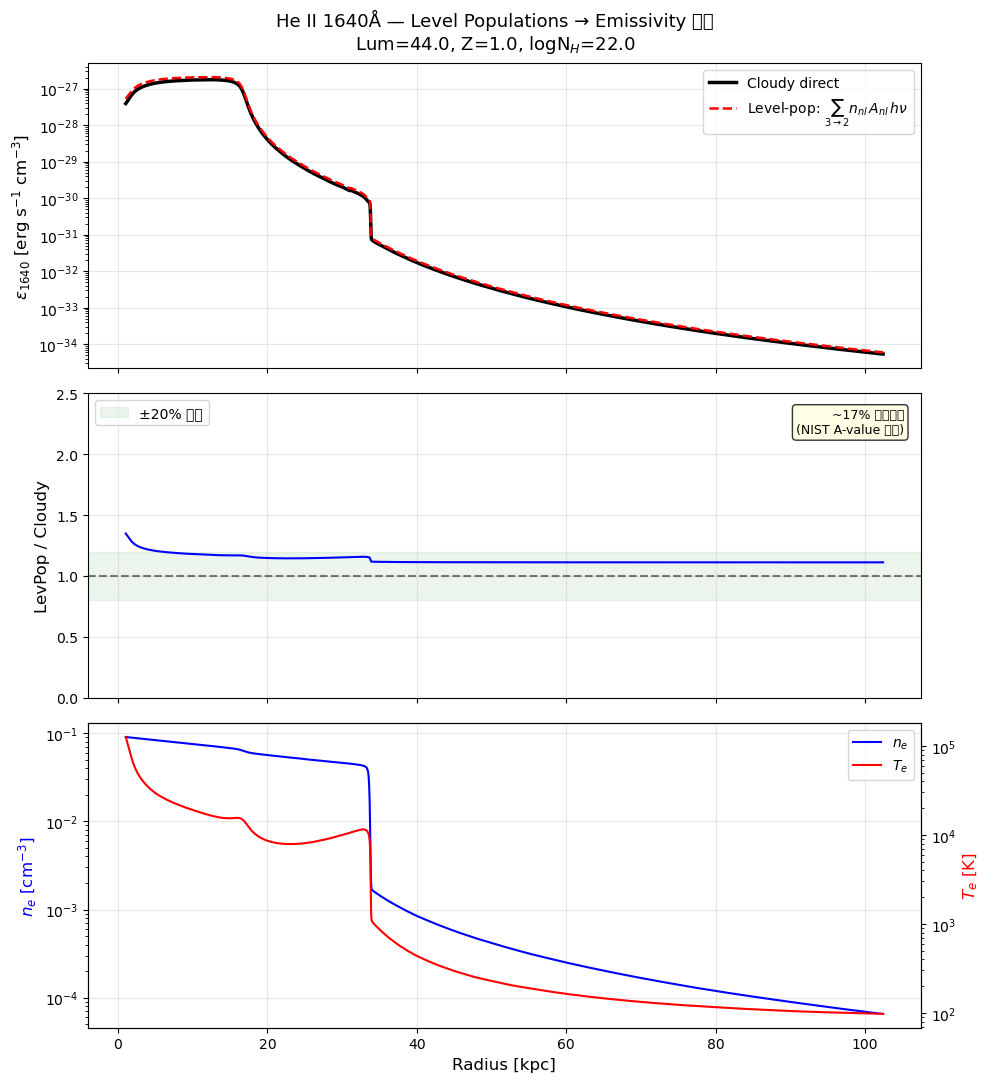

In [16]:
# ── Level Populations → Emissivity 검증 플롯 ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
fig.suptitle('He II 1640Å — Level Populations → Emissivity 검증\n'
             'Lum=44.0, Z=1.0, logN$_H$=22.0', fontsize=13)

ax = axes[0]
ax.semilogy(r_lp_kpc, emis_c_lp, 'k-',  lw=2.5, label='Cloudy direct')
valid_lp = emis_levpop > 0
ax.semilogy(r_lp_kpc[valid_lp], emis_levpop[valid_lp], 'r--', lw=1.8,
            label=r'Level-pop: $\sum_{3\to2} n_{nl}\,A_{nl}\,h\nu$')
ax.set_ylabel(r'$\varepsilon_{1640}$ [erg s$^{-1}$ cm$^{-3}$]', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ratio_lp = np.where(emis_c_lp > 0, emis_levpop / emis_c_lp, np.nan)
ax.plot(r_lp_kpc, ratio_lp, 'b-', lw=1.5)
ax.axhline(1.0, color='k', ls='--', alpha=0.5)
ax.axhspan(0.8, 1.2, alpha=0.08, color='green', label='±20% 범위')
ax.set_ylabel('LevPop / Cloudy', fontsize=12)
ax.set_ylim(0, 2.5)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.text(0.98, 0.95, '~17% 과대평가\n(NIST A-value 근사)', transform=ax.transAxes,
        fontsize=9, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

ax = axes[2]
ax_te = ax.twinx()
l1, = ax.semilogy(r_lp_kpc, ne_lp, 'b-', lw=1.5, label='$n_e$')
l2, = ax_te.semilogy(r_lp_kpc, Te_lp, 'r-', lw=1.5, label='$T_e$')
ax.set_ylabel('$n_e$ [cm$^{-3}$]', fontsize=12, color='b')
ax_te.set_ylabel('$T_e$ [K]', fontsize=12, color='r')
ax.set_xlabel('Radius [kpc]', fontsize=12)
ax.legend(handles=[l1, l2], fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/RT_JIN/HeII_levpop_verify_nb.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 12. He II 1640Å vs C IV 1548+1550Å 비교

CIV 1548/1550Å는 Li-like C³⁺의 **공명 이중선**이다:

$$\mathrm{C}^{3+}\;\;2p\;{}^2P_{3/2,\,1/2} \;\longrightarrow\; 2s\;{}^2S_{1/2}$$

- CIV는 He II와 달리 **주로 충돌 여기(collisional excitation)** 로 방출됨
- He II 1640Å는 **재결합선** → He³⁺ 이온화 구조에 민감
- CIV 1548+1550은 **C³⁺ 이온화 구조 + 전자 온도**에 민감
- QSO CGM 모델에서 CIV/HeII 비율은 **이온화 파라미터와 금속량 진단자**로 활용

`.emis` 파일 컬럼 (공통 line list):

| col | 라인 |
|---|---|
| 10 | He II 1640.43Å |
| 15 | C IV 1550.78Å  (uppercase C 4) |
| 19 | C IV 1548.19Å  |
| 20 | C IV 1550.78Å  |

두 가지 모델에서 비교:
- **Lum=44.0, logN_H=22.0** (`level_pop_test`)
- **Lum=42.0, logN_H=20.5** (노트북 기본 모델)

In [17]:
# ── 공통 .emis 로더 ───────────────────────────────────────────────────────────
def load_emis(emis_path, rad_path, phy_path):
    emis = np.genfromtxt(emis_path, skip_header=1)
    rad  = np.genfromtxt(rad_path,  skip_header=1)
    phy  = np.genfromtxt(phy_path,  skip_header=1)
    nz   = min(len(emis), len(rad), len(phy))
    return {
        'r_kpc':     rad[:nz, 1] / kpc,
        'Te':        phy[:nz, 1],
        'ne':        phy[:nz, 3],
        'HeII_1640': emis[:nz, 10],
        'CIV_1548':  emis[:nz, 19],
        'CIV_1550':  emis[:nz, 20],
        'CIV_total': emis[:nz, 19] + emis[:nz, 20],
    }

# ── C 이온 분율 로더 (col 4 = C+3 = C IV) ────────────────────────────────────
def load_CIV_frac(ele_C_path, rad_path):
    ele  = np.genfromtxt(ele_C_path, skip_header=1)
    rad  = np.genfromtxt(rad_path,   skip_header=1)
    nz   = min(len(ele), len(rad))
    return {
        'r_kpc': rad[:nz, 1] / kpc,
        'CI':    ele[:nz, 1],
        'CII':   ele[:nz, 2],
        'CIII':  ele[:nz, 3],
        'CIV':   ele[:nz, 4],
        'CV':    ele[:nz, 5],
        'CVI':   ele[:nz, 6],
    }

# ── 두 모델 로드 ──────────────────────────────────────────────────────────────
# Model A: Lum=44.0, logN_H=22.0 (level_pop_test)
dirA    = os.path.expanduser('~/RT_JIN/level_pop_test')
modA    = load_emis(f'{dirA}/CLOUDY_QSO_pop.emis',
                    f'{dirA}/CLOUDY_QSO_pop.rad',
                    f'{dirA}/CLOUDY_QSO_pop.phy')
civA    = load_CIV_frac(f'{dirA}/CLOUDY_QSO_pop.ele_C',
                        f'{dirA}/CLOUDY_QSO_pop.rad')

# Model B: Lum=42.0, logN_H=20.5 (notebook main model)
dirB    = os.path.expanduser(
    '~/CIV_RT_scat_data/CLOUDY_setup/Lum_42.0_2/metal_1.0/N_H_3.2_20.0/CIV')
modB    = load_emis(f'{dirB}/CLOUDY_QSO.emis',
                    f'{dirB}/CLOUDY_QSO.rad',
                    f'{dirB}/CLOUDY_QSO.phy')
civB    = load_CIV_frac(f'{dirB}/CLOUDY_QSO.ele_C',
                        f'{dirB}/CLOUDY_QSO.rad')

# 적분 요약
for label, m in [('Lum=44.0, logN=22.0', modA), ('Lum=42.0, logN=20.5', modB)]:
    r_cm = m['r_kpc'] * kpc
    i_he  = np.trapz(m['HeII_1640'], r_cm)
    i_civ = np.trapz(m['CIV_total'], r_cm)
    print(f'{label}:')
    print(f'  ∫ He II 1640 dr = {i_he:.3e} erg/s/cm²')
    print(f'  ∫ CIV 1548+50  dr = {i_civ:.3e} erg/s/cm²')
    print(f'  CIV / HeII 비율   = {i_civ/i_he:.2f}')

Lum=44.0, logN=22.0:
  ∫ He II 1640 dr = 7.268e-05 erg/s/cm²
  ∫ CIV 1548+50  dr = 9.998e-05 erg/s/cm²
  CIV / HeII 비율   = 1.38
Lum=42.0, logN=20.5:
  ∫ He II 1640 dr = 1.695e-07 erg/s/cm²
  ∫ CIV 1548+50  dr = 1.070e-07 erg/s/cm²
  CIV / HeII 비율   = 0.63


Font 'default' does not have a glyph for '\uae30' [U+ae30], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubcf8' [U+bcf8], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubaa8' [U+baa8], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub378' [U+b378], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uae30' [U+ae30], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubcf8' [U+bcf8], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubaa8' [U+baa8], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub378' [U+b378], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uae30' [U+ae30], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubcf8' [U+bcf8], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubaa8' [U+baa8], 

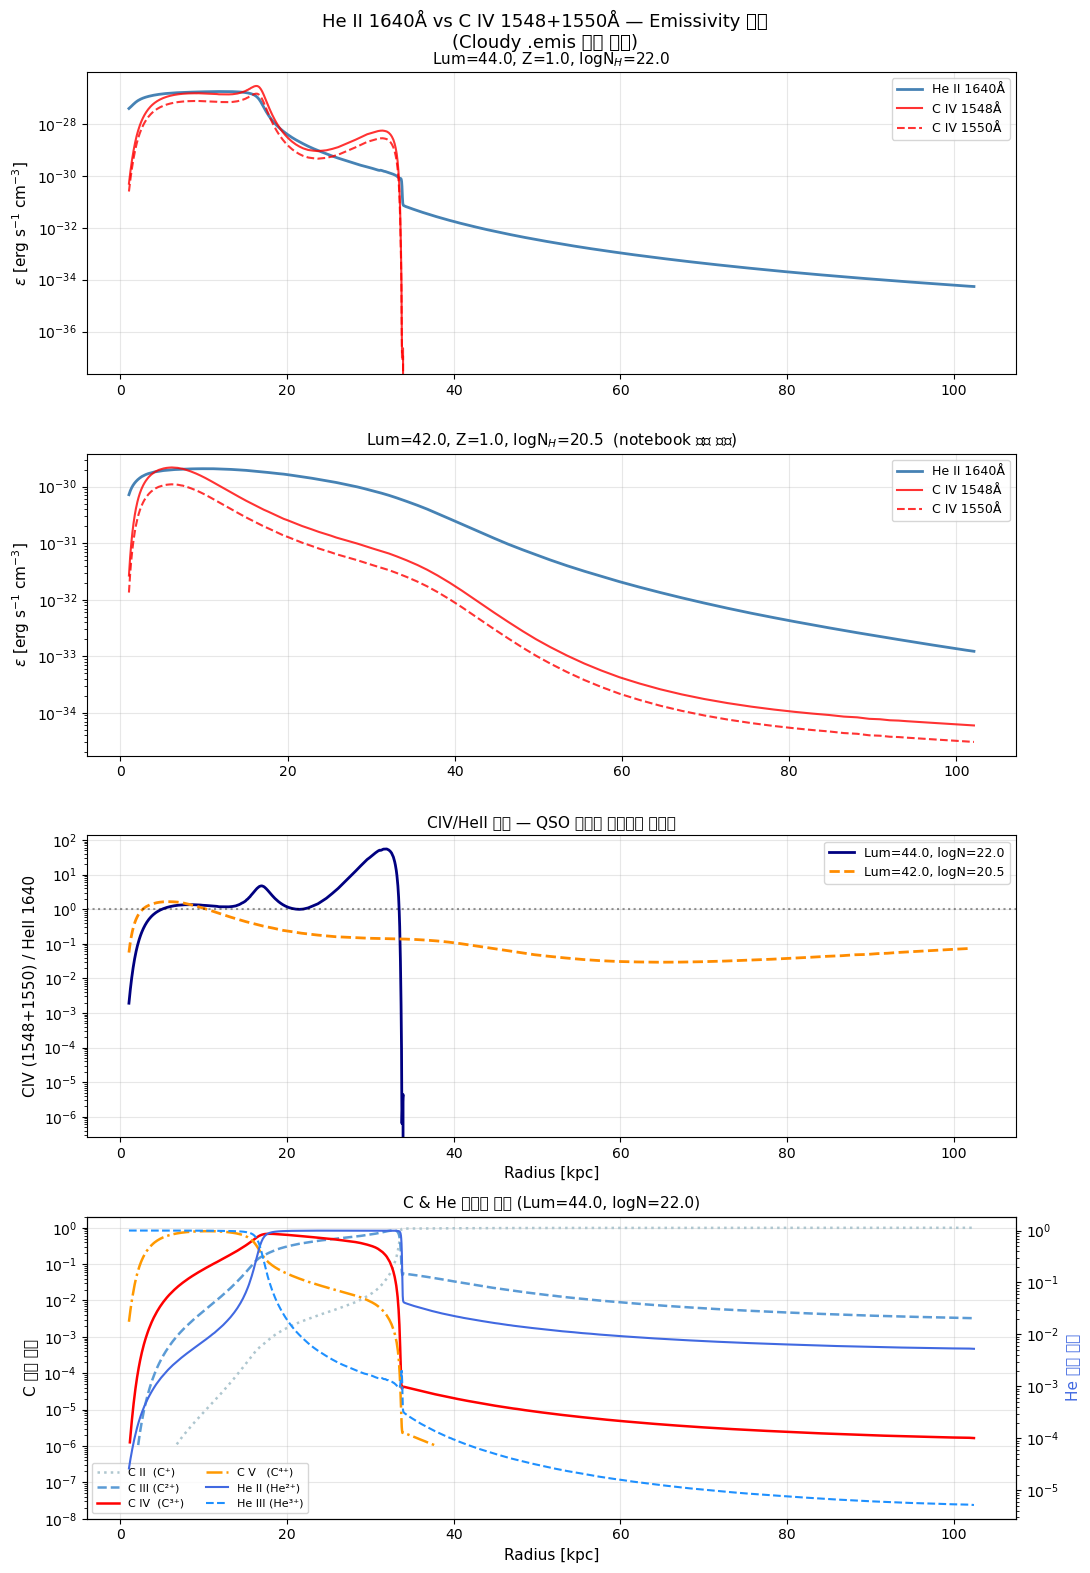

In [18]:
fig, axes = plt.subplots(4, 1, figsize=(11, 16), sharex=False)
fig.suptitle('He II 1640Å vs C IV 1548+1550Å — Emissivity 비교\n'
             '(Cloudy .emis 직접 읽기)', fontsize=13)

# ── (1) Emissivity 프로파일 — Model A (Lum=44) ───────────────────────────────
ax = axes[0]
ax.semilogy(modA['r_kpc'], modA['HeII_1640'], 'steelblue', lw=2,
            label='He II 1640Å')
ax.semilogy(modA['r_kpc'], modA['CIV_1548'],  'r-',       lw=1.5,
            label='C IV 1548Å', alpha=0.8)
ax.semilogy(modA['r_kpc'], modA['CIV_1550'],  'r--',      lw=1.5,
            label='C IV 1550Å', alpha=0.8)
ax.set_ylabel(r'$\varepsilon$ [erg s$^{-1}$ cm$^{-3}$]', fontsize=11)
ax.set_title('Lum=44.0, Z=1.0, logN$_H$=22.0', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── (2) Emissivity 프로파일 — Model B (Lum=42) ───────────────────────────────
ax = axes[1]
ax.semilogy(modB['r_kpc'], modB['HeII_1640'], 'steelblue', lw=2,
            label='He II 1640Å')
ax.semilogy(modB['r_kpc'], modB['CIV_1548'],  'r-',       lw=1.5,
            label='C IV 1548Å', alpha=0.8)
ax.semilogy(modB['r_kpc'], modB['CIV_1550'],  'r--',      lw=1.5,
            label='C IV 1550Å', alpha=0.8)
ax.set_ylabel(r'$\varepsilon$ [erg s$^{-1}$ cm$^{-3}$]', fontsize=11)
ax.set_title('Lum=42.0, Z=1.0, logN$_H$=20.5  (notebook 기본 모델)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── (3) CIV / HeII 비율 ───────────────────────────────────────────────────────
ax = axes[2]
for label, m, ls, col in [
        ('Lum=44.0, logN=22.0', modA, '-',  'navy'),
        ('Lum=42.0, logN=20.5', modB, '--', 'darkorange')]:
    ratio_r = np.where(m['HeII_1640'] > 0,
                       m['CIV_total'] / m['HeII_1640'], np.nan)
    ax.semilogy(m['r_kpc'], np.abs(ratio_r), ls=ls, lw=2, color=col, label=label)
ax.axhline(1.0, color='k', ls=':', alpha=0.4)
ax.set_ylabel('CIV (1548+1550) / HeII 1640', fontsize=11)
ax.set_xlabel('Radius [kpc]', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title('CIV/HeII 비율 — QSO 이온화 파라미터 진단자', fontsize=11)

# ── (4) C 이온화 분율 vs He 이온화 분율 (Model A) ──────────────────────────
ax = axes[3]
ax2 = ax.twinx()
for key, lbl, col, ls in [
        ('CII',  'C II  (C⁺)',  '#aec6cf', ':'),
        ('CIII', 'C III (C²⁺)', '#5b9bd5', '--'),
        ('CIV',  'C IV  (C³⁺)', 'red',     '-'),
        ('CV',   'C V   (C⁴⁺)', '#ff9900', '-.')]:
    v = civA[key]
    valid = v > 1e-6
    if valid.sum() > 2:
        ax.semilogy(civA['r_kpc'][valid], v[valid], color=col, ls=ls, lw=1.8, label=lbl)

# He 이온화도 같이 (He III 분율) — .ele_He 로드
ele_He_A = np.genfromtxt(f'{dirA}/CLOUDY_QSO_pop.ele_He', skip_header=1)
nz_he    = min(len(ele_He_A), len(modA['r_kpc']))
r_he     = modA['r_kpc'][:nz_he]
for stage, lbl, col, ls in [
        (2, 'He II (He²⁺)', 'royalblue',   '-'),
        (3, 'He III (He³⁺)', 'dodgerblue', '--')]:
    v = ele_He_A[:nz_he, stage]
    valid = v > 1e-6
    if valid.sum() > 2:
        ax2.semilogy(r_he[valid], v[valid], color=col, ls=ls, lw=1.5, label=lbl)

ax.set_ylabel('C 이온 분율', fontsize=11)
ax2.set_ylabel('He 이온 분율', fontsize=11, color='royalblue')
ax.set_xlabel('Radius [kpc]', fontsize=11)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, ncol=2, loc='lower left')
ax.set_title('C & He 이온화 구조 (Lum=44.0, logN=22.0)', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(1e-8, 2)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/RT_JIN/HeII_vs_CIV_nb.png'),
            dpi=150, bbox_inches='tight')
plt.show()